In [1]:
import math
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import os
import scipy.sparse as sp

from reaction_diffusion.routines.tomo_fusion.tools import plotting_fcts as tomo_plots

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True, warn_only=True)

from helpers import *

device: cuda


In [2]:
H, W = 120, 40


# select samples to be used for normalization procedure
samples_idxs = np.arange(0,1000)
train_samples_path = Path(f"../../data/sxr_data/sxr_profiles_coarse")
train_samples_normalization = []
for sample_id_ in samples_idxs:
    path = os.path.join(train_samples_path, f"sxr_sample_{sample_id_}.npy")
    train_samples_normalization.append(np.load(path))
train_samples_normalization = torch.from_numpy(np.array(train_samples_normalization, dtype=np.float32)).to(device)

# load forward model
A_path = Path("forward_model/forward_model_sxr_full_geometry.npy")
A_sparse = np.load(A_path).astype(np.float32)
A_sparse /= A_sparse.max()  # normalize for better conditioning
print(A_sparse.min(), A_sparse.max(), A_sparse.shape)
A_tomo = torch.from_numpy(A_sparse).to(device)

# compute y_tomo distribution
y_tomo_train = train_samples_normalization.reshape(-1, H * W) @ A_tomo.T


0.0 1.0 (100, 4800)


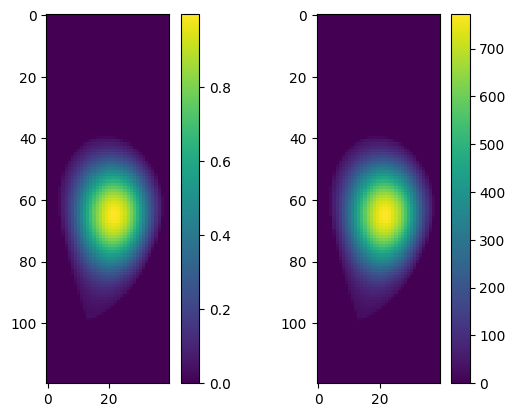

In [3]:
# load test samples
test_samples_path = Path(f"/home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples/sxr_samples_with_background_coarse.npy")
test_samples = torch.tensor(np.load(test_samples_path), dtype=torch.float32).to(device)

# compute y_tomo distribution for test samples
y_tomo_test = test_samples.reshape(-1, H * W) @ A_tomo.T

# deform distribution
test_samples_deformed = test_samples * torch.rand(test_samples.shape[0], device=device).reshape(-1,1,1) * 1000 

# compute y_tomo deformed distribution for test samples
y_tomo_test = test_samples_deformed.reshape(-1, H * W) @ A_tomo.T

plt.Figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(test_samples[16,:].cpu().numpy())
plt.colorbar()
plt.subplot(1, 2, 2)
plt.imshow(test_samples_deformed[16,:].cpu().numpy())
plt.colorbar()
plt.show()


In [4]:
def compute_closest_y(y, y_tomo_train):
    # Find the closest y_tomo_train to y
    y_norm = y / torch.norm(y, dim=1, keepdim=True)
    y_tomo_train_norm = y_tomo_train / torch.norm(y_tomo_train, dim=1, keepdim=True)
    idx = torch.argmin(torch.cdist(y_norm, y_tomo_train_norm))
    y_closest = y_tomo_train[idx]
    return y_closest

def compute_normalization_coefficient(y, y_tomo_train):
    y_closest = compute_closest_y(y, y_tomo_train).squeeze()
    coeff = torch.dot(y.squeeze(), y_closest) / torch.dot(y_closest, y_closest)
    return coeff.item()

In [5]:
closest = compute_closest_y(y_tomo_train[16,:].reshape(1, -1), y_tomo_train)
closest_test = compute_closest_y(y_tomo_test[16,:].reshape(1, -1), y_tomo_train)

# compute aplha
alpha = compute_normalization_coefficient(y_tomo_test[16,:].reshape(1, -1), y_tomo_train)
print("alpha:", alpha)

alpha: 861.6143188476562


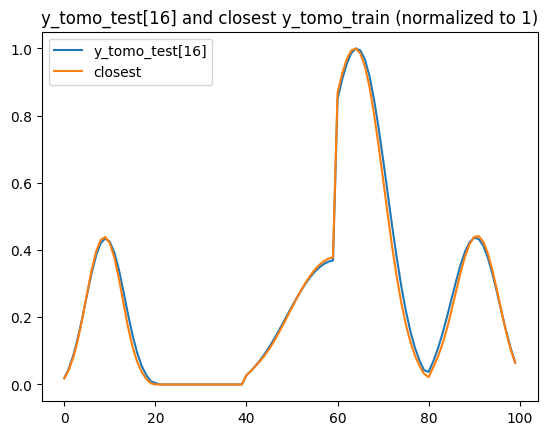

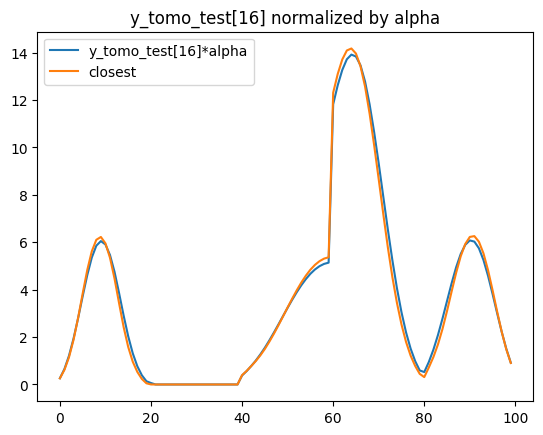

In [6]:
plt.plot(y_tomo_test[16,:].cpu().numpy()/y_tomo_test[16,:].cpu().numpy().max(), label="y_tomo_test[16]")
plt.plot(closest_test.cpu().numpy()/closest_test.cpu().numpy().max(), label="closest")
plt.legend()
plt.title("y_tomo_test[16] and closest y_tomo_train (normalized to 1)")
plt.show()  

plt.plot(y_tomo_test[16,:].cpu().numpy() / alpha, label="y_tomo_test[16]*alpha")
plt.plot(closest_test.cpu().numpy(), label="closest")
plt.legend()
plt.title("y_tomo_test[16] normalized by alpha")
plt.show()


In [18]:
y_tomo_train[16,:].reshape(-1, 1).shape

torch.Size([100, 1])

In [19]:
sample_idx = 9 #122, 2 , 9, 12

In [7]:
import scipy.sparse as sp
import numpy as np
import copy
import matplotlib.pyplot as plt
import os
import skimage.transform as skimt
import sys
from pathlib import Path

import reaction_diffusion.routines.tomo_fusion.tools.helpers as tomo_helps
import reaction_diffusion.routines.tomo_fusion.functionals_definition as fct_def
import reaction_diffusion.routines.tomo_fusion.hyperparameter_tuning as hyper_tune
import reaction_diffusion.routines.tomo_fusion.bayesian_computations as bcomp

indices = np.arange(0, 100)
samples_dir = Path(f'/home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples')

# Load phantom data
psis = np.load(os.path.join(samples_dir, 'psis_coarse.npy'))[indices, :]
sxr_samples = np.load(os.path.join(samples_dir, 'sxr_samples_with_background_coarse.npy'))[indices, :]
alphas = np.load(os.path.join(samples_dir, 'alpha_random_values.npy'))[indices]
trim_val = np.load(os.path.join(samples_dir, 'trimming_values.npy'))[indices, :]

tcv_mask = np.load("/home/fusiontomo/Repos/diffusion_tomography/reaction_diffusion/routines/tcv_mask_1_subpixels_NINO.npy")
tcv_mask = skimt.resize(tcv_mask, (120, 40), anti_aliasing=False, mode='edge')
tcv_mask[tcv_mask>0]=1

# load forward model
fwd_model = np.load("/home/fusiontomo/Repos/diffusion_tomography/forward_model/forward_model_sxr_full_geometry.npy")
max_fwd_model = np.max(fwd_model)
fwd_model = sp.csr_matrix(fwd_model)
normalized_fwd_model = fwd_model / max_fwd_model
reconstruction_shape = (120,40)

# error level on data, computed as 0.05 times the average of the tomographic measurements on 1000 training phantoms
sigma_err_noise = (3.5e-11 / max_fwd_model)
# sigma_err_recon = 0.02 # sigma in reconstruction ("normalized" value)
normalization_to_one_factor = 1 # no normalization

reg_param_tuning_data = []


/home/dhamm/miniconda3/envs/fusion/lib/python3.12/site-packages/pyxu/info/plugin.py:70: ContributionWarning: Plugin `pyxu_diffops.operator:AnisCoherenceEnhancingDiffusionOp` loaded.
  warnings.warn(msg, pxw.ContributionWarning)
/home/dhamm/miniconda3/envs/fusion/lib/python3.12/site-packages/pyxu/info/plugin.py:70: ContributionWarning: Plugin `pyxu_diffops.operator:AnisDiffusionOp` loaded.
  warnings.warn(msg, pxw.ContributionWarning)
/home/dhamm/miniconda3/envs/fusion/lib/python3.12/site-packages/pyxu/info/plugin.py:70: ContributionWarning: Plugin `pyxu_diffops.operator:AnisEdgeEnhancingDiffusionOp` loaded.
  warnings.warn(msg, pxw.ContributionWarning)
/home/dhamm/miniconda3/envs/fusion/lib/python3.12/site-packages/pyxu/info/plugin.py:70: ContributionWarning: Plugin `pyxu_diffops.operator:CurvaturePreservingDiffusionOp` loaded.
  warnings.warn(msg, pxw.ContributionWarning)
/home/dhamm/miniconda3/envs/fusion/lib/python3.12/site-packages/pyxu/info/plugin.py:70: ContributionWarning: Plugi

In [ ]:
for idx in indices:
    print("Phantom ", idx)
    ground_truth = copy.deepcopy(sxr_samples[idx, :, :].squeeze())
    psi = psis[idx, :, :]
    alpha = alphas[idx]
    trim_val_ = trim_val[idx, :]
    #mask_core = tomo_helps.define_core_mask(psi=psi, dim_shape=reconstruction_shape, trim_values_x=trim_val_)

    # anisotropic regularization functional
    reg_fct_type = "anisotropic"
    # Define functionals
    f, g = fct_def.define_loglikelihood_and_logprior(ground_truth=ground_truth, psi=psi, fwd_matrix=normalized_fwd_model,
                                                        sigma_err=sigma_err_noise, reg_fct_type=reg_fct_type,
                                                        alpha=alpha, plot=False,
                                                        seed=idx)
    # normalized_data = f.noisy_tomo_data / ( max_fwd_model)
    # normalization_to_one_factor = np.max(normalized_data) # scaling factor to have data around 1, undone after reconstruction to compute MSE with original ground truth
    # f_recon = fct_def._DataFidelityFunctional(dim_shape=(1,120,40), noisy_tomo_data=( normalized_data / normalization_to_one_factor ),
    #                                           sigma_err=sigma_err_recon, geometry_matrix=normalized_fwd_model)
    # tune hyperparameters
    reg_param_data_idx = hyper_tune.reg_param_tuning(f, g, tuning_techniques=["GT"], ground_truth=ground_truth,
                                                        with_pos_constraint=True, clipping_mask=tcv_mask,
                                                        cv_strategy="random", map_scaling_factor=normalization_to_one_factor,
                                                        reg_params=np.logspace(-1, 3, 13), plot=False)

    reg_param_tuning_data.append(reg_param_data_idx)

Phantom  0
Tuning regularization parameter: comparison to ground truth (`GT`)



In [ ]:
print(sigma_err_noise, alpha)

0.2437959324685185 0.01


In [8]:
reg_fct_type = "anisotropic"
alpha=1e-2
# Define functionals
f, g = fct_def.define_loglikelihood_and_logprior(ground_truth=ground_truth, psi=psi, fwd_matrix=normalized_fwd_model,
                                                        sigma_err=sigma_err_noise, reg_fct_type=reg_fct_type,
                                                        alpha=alpha, plot=False,
                                                        seed=idx)
# # Define functionals
# f, g = fct_def.define_loglikelihood_and_logprior(ground_truth=ground_truth, psi=psi, fwd_matrix=fwd_model,
#                                                         sigma_err=3.5e-11, reg_fct_type=reg_fct_type,
#                                                         alpha=alpha, plot=False,
#                                                         seed=idx)

NameError: name 'ground_truth' is not defined

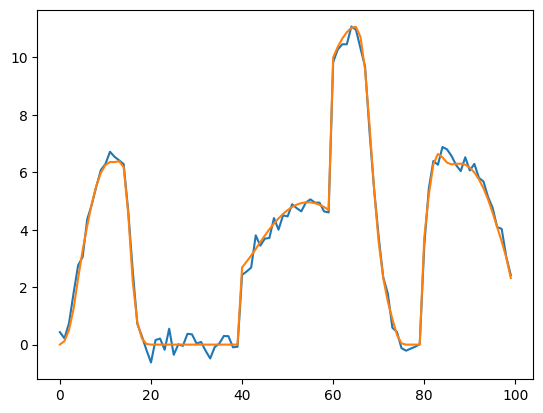

In [ ]:
plt.plot(f.noisy_tomo_data)
plt.plot(f.tomo_data)

In [ ]:
reg_param = 1e-2

im_MAP = bcomp.compute_MAP(f, g, reg_param, with_pos_constraint=True, clipping_mask=tcv_mask, show_progress=False)


In [ ]:
reg_param = 1e-1

sigma_err_recon = 0.02
mask_core = tomo_helps.define_core_mask(psi=psi, dim_shape=reconstruction_shape, trim_values_x=trim_val_)

normalized_data = f.noisy_tomo_data
normalization_to_one_factor = np.max(normalized_data) # scaling factor to have data around 1, undone after reconstruction to compute MSE with original ground truth
f_recon = fct_def._DataFidelityFunctional(dim_shape=(1,120,40), noisy_tomo_data=( normalized_data / normalization_to_one_factor ),
                                            sigma_err=sigma_err_recon, geometry_matrix=normalized_fwd_model)
im_MAP = bcomp.compute_MAP(f_recon, g, reg_param, with_pos_constraint=True, clipping_mask=mask_core, show_progress=False)

im_MAP *= normalization_to_one_factor



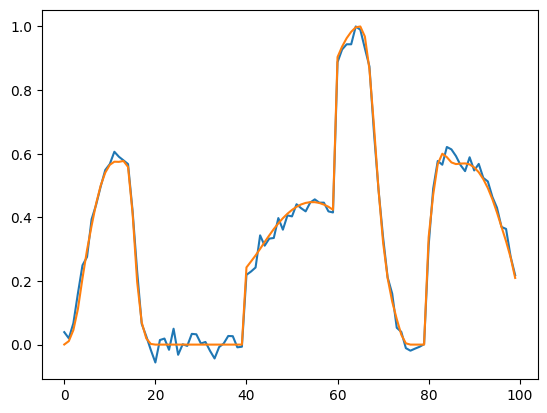

In [ ]:
plt.plot(f_recon.noisy_tomo_data)
plt.plot(f.tomo_data/f.tomo_data.max())

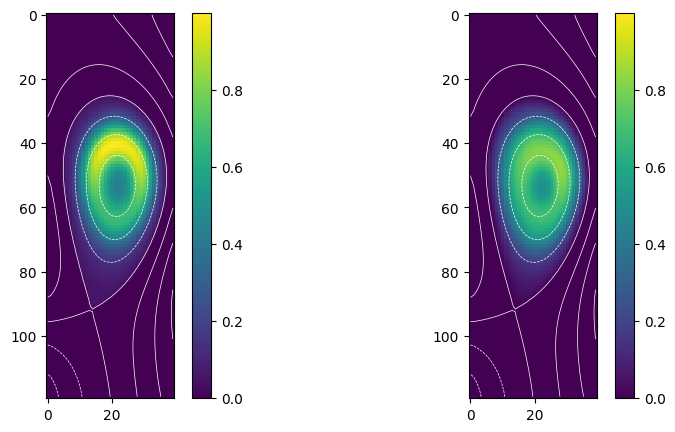

In [ ]:
idx = 37

ground_truth = copy.deepcopy(sxr_samples[idx, :, :].squeeze())
psi = psis[idx, :, :]
alpha = alphas[idx]
trim_val_ = trim_val[idx, :]

reg_param = 1e-1
alpha=1e-2
# Define functionals
mask_core = tomo_helps.define_core_mask(psi=psi, dim_shape=reconstruction_shape, trim_values_x=trim_val_)
f, g = fct_def.define_loglikelihood_and_logprior(ground_truth=ground_truth, psi=psi, fwd_matrix=normalized_fwd_model,
                                                        sigma_err=sigma_err_noise, reg_fct_type=reg_fct_type,
                                                        alpha=alpha, plot=False,
                                                        seed=idx)
im_MAP = bcomp.compute_MAP(f, g, reg_param, with_pos_constraint=True, clipping_mask=mask_core, show_progress=False)



vmax=np.max([ground_truth.max(), im_MAP.max()])
fig, ax= plt.subplots(1, 2, figsize=(10, 5))
im=ax[0].imshow(ground_truth, vmax=vmax)
plt.colorbar(im,ax=ax[0])
ax[0].contour(psi, colors='w', linewidths=0.5)
im=ax[1].imshow(im_MAP, vmax=vmax)
plt.colorbar(im,ax=ax[1])
ax[1].contour(psi, colors='w', linewidths=0.5)

In [39]:
best_hyper = np.load("reaction_diffusion/phantom_studies/tuning_data/reg_param_tuning_sigma002/best_hyperparams.npy", allow_pickle=True)
nb_occurrences = np.load("reaction_diffusion/phantom_studies/tuning_data/reg_param_tuning_sigma002/nb_occurrences.npy", allow_pickle=True)

<Figure size 640x480 with 0 Axes>

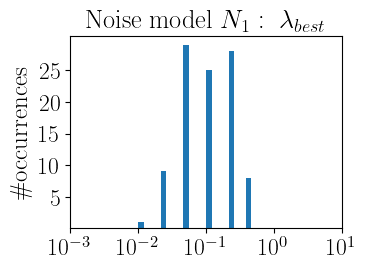

In [46]:
plt.figure()

plt.figure(figsize=(3.5,2.5))
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
})


vec = np.zeros(100)
counter=0
for i in range(13):
    vec[counter:counter+int(nb_occurrences[i])] = i
    counter += int(nb_occurrences[i])

plt.hist(vec, bins=20)
plt.xticks([0,3,6,9,12], [r"$10^{-3}$", r"$10^{-2}$", r"$10^{-1}$", r"$10^{0}$", r"$10^{1}$"], fontsize=17)
plt.yticks([5,10,15,20,25], fontsize=17) 
plt.title(r"$\mathrm{Noise \;model \;}N_1:\;\lambda_{best}$", fontsize=19)

plt.ylabel(r"$\# \mathrm{occurrences}$", fontsize=18, labelpad=5)

plt.show()

In [42]:
np.logspace(-3, 1, 13)

array([1.00000000e-03, 2.15443469e-03, 4.64158883e-03, 1.00000000e-02,
       2.15443469e-02, 4.64158883e-02, 1.00000000e-01, 2.15443469e-01,
       4.64158883e-01, 1.00000000e+00, 2.15443469e+00, 4.64158883e+00,
       1.00000000e+01])

In [47]:
nb_occurrences

array([ 0.,  0.,  0.,  1.,  9., 29., 25., 28.,  8.,  0.,  0.,  0.,  0.])

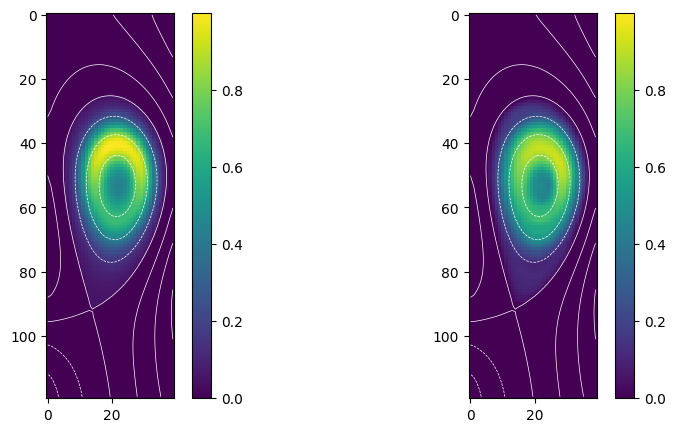

In [27]:
idx = 37

ground_truth = copy.deepcopy(sxr_samples[idx, :, :].squeeze())
psi = psis[idx, :, :]
alpha = alphas[idx]
trim_val_ = trim_val[idx, :]

reg_param = 14.3**2 * 1e-1
alpha=1e-2
sigma_err_recon = 0.02
# Define functionals
mask_core = tomo_helps.define_core_mask(psi=psi, dim_shape=reconstruction_shape, trim_values_x=trim_val_)
f, g = fct_def.define_loglikelihood_and_logprior(ground_truth=ground_truth, psi=psi, fwd_matrix=normalized_fwd_model,
                                                        sigma_err=sigma_err_noise, reg_fct_type=reg_fct_type,
                                                        alpha=alpha, plot=False,
                                                        seed=idx)
normalized_data = f.noisy_tomo_data
normalization_to_one_factor = np.max(normalized_data) # scaling factor to have data around 1, undone after reconstruction to compute MSE with original ground truth
f_recon = fct_def._DataFidelityFunctional(dim_shape=(1,120,40), noisy_tomo_data=( normalized_data / normalization_to_one_factor ),
                                            sigma_err=sigma_err_recon, geometry_matrix=normalized_fwd_model)
im_MAP = bcomp.compute_MAP(f_recon, g, reg_param, with_pos_constraint=True, clipping_mask=mask_core, show_progress=False)
im_MAP *= normalization_to_one_factor


vmax=np.max([ground_truth.max(), im_MAP.max()])
fig, ax= plt.subplots(1, 2, figsize=(10, 5))
im=ax[0].imshow(ground_truth, vmax=vmax)
plt.colorbar(im,ax=ax[0])
ax[0].contour(psi, colors='w', linewidths=0.5)
im=ax[1].imshow(im_MAP, vmax=vmax)
plt.colorbar(im,ax=ax[1])
ax[1].contour(psi, colors='w', linewidths=0.5)

In [29]:
14.3**2*1e-1

20.449

In [26]:
f.tomo_data.max()

np.float64(14.315625636986345)

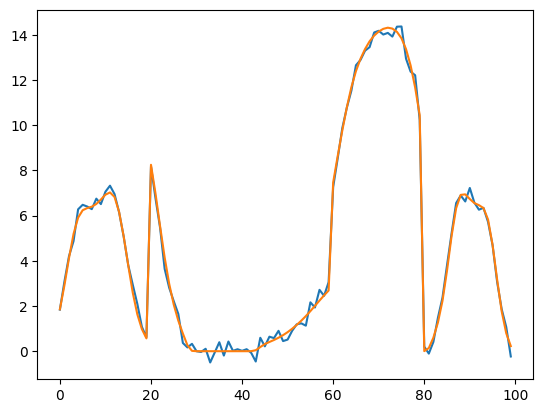

In [25]:
plt.plot(f.noisy_tomo_data)
plt.plot(f.tomo_data)

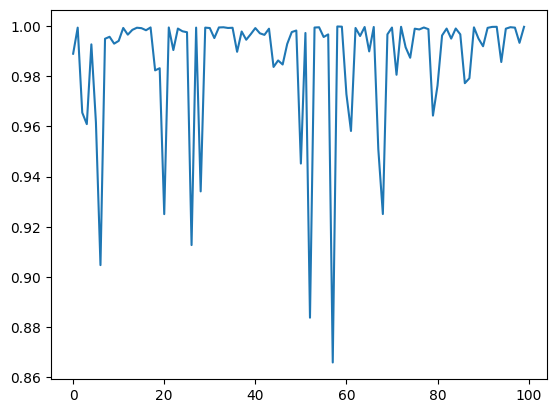

In [ ]:
plt.plot(sxr_samples.max(axis=(1,2)))

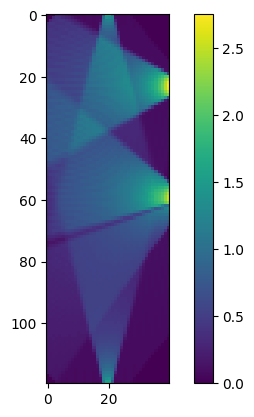

In [ ]:
plt.imshow(normalized_fwd_model.sum(axis=0).reshape(120,40))
plt.colorbar()

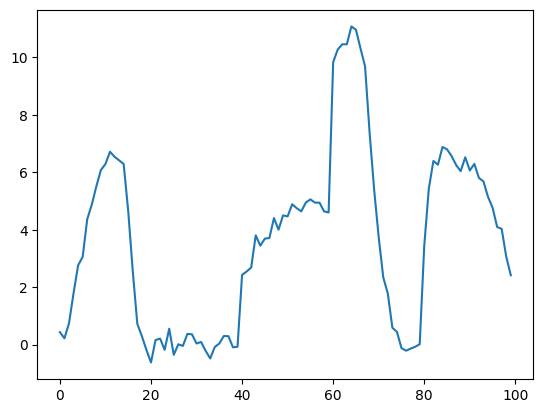

In [ ]:
plt.plot(f.noisy_tomo_data)

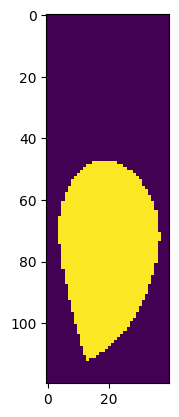

In [ ]:
plt.imshow(mask_core)

In [ ]:
sigma_err_noise

np.float64(0.2437959324685185)

In [ ]:
y

np.float64(1.0)

In [ ]:
for idx in indices:
    print("Phantom ", idx)
    ground_truth = copy.deepcopy(sxr_samples[idx, :, :].squeeze())
    psi = psis[idx, :, :]
    alpha = alphas[idx]
    trim_val_ = trim_val[idx, :]
    #mask_core = tomo_helps.define_core_mask(psi=psi, dim_shape=reconstruction_shape, trim_values_x=trim_val_)

    # anisotropic regularization functional
    reg_fct_type = "anisotropic"
    # Define functionals
    f, g = fct_def.define_loglikelihood_and_logprior(ground_truth=ground_truth, psi=psi, fwd_matrix=normalized_fwd_model,
                                                        sigma_err=sigma_err_noise, reg_fct_type=reg_fct_type,
                                                        alpha=alpha, plot=False,
                                                        seed=idx)
    # normalized_data = f.noisy_tomo_data / ( max_fwd_model)
    # normalization_to_one_factor = np.max(normalized_data) # scaling factor to have data around 1, undone after reconstruction to compute MSE with original ground truth
    # f_recon = fct_def._DataFidelityFunctional(dim_shape=(1,120,40), noisy_tomo_data=( normalized_data / normalization_to_one_factor ),
    #                                           sigma_err=sigma_err_recon, geometry_matrix=normalized_fwd_model)
    # tune hyperparameters
    reg_param_data_idx = hyper_tune.reg_param_tuning(f, g, tuning_techniques=["GT"], ground_truth=ground_truth,
                                                        with_pos_constraint=True, clipping_mask=tcv_mask,
                                                        cv_strategy="random", map_scaling_factor=normalization_to_one_factor,
                                                        reg_params=np.logspace(-1, 3, 13), plot=False)

    reg_param_tuning_data.append(reg_param_data_idx)

best_performing_hyper_params = np.zeros(len(reg_param_tuning_data))
for i in range(best_performing_hyper_params.size):
    mse_argmin = np.argmin(reg_param_tuning_data[i]['GT'][2, :])
    best_performing_hyper_params[i] = reg_param_tuning_data[i]['GT'][0, mse_argmin]

nb_occurrences = np.zeros(reg_param_tuning_data[0]["GT"].shape[1])
for i in range(len(reg_param_tuning_data)):
    j = np.argmin(reg_param_tuning_data[i]['GT'][2, :])
    nb_occurrences[j] += 1

plt.figure()
plt.plot(nb_occurrences)
plt.xticks([0,4,8,12,16,20], [r"$10^{-4}$", r"$10^{-3}$", r"$10^{-2}$", r"$10^{-1}$", r"$10^{0}$", r"$10^{1}$"])
plt.title(r"Regularization parameter $\lambda$ minimizing MSE (anisotropic)")
plt.xlabel(r"$\lambda$")
plt.ylabel("# occurrences")
plt.show()

print("Statistics on best performing regularization parameter (anisotropic)\n")
print("Mean ", np.mean(best_performing_hyper_params))
print("Median ", np.median(best_performing_hyper_params))
print("Standard deviation ", np.std(best_performing_hyper_params))

# Define regularization parameter as average/median best performing value
reg_param_mean = np.mean(best_performing_hyper_params)
reg_param_median = np.median(best_performing_hyper_params)

# ratio of MSE with average regularization parameter vs best MSE
factors_average_wrt_best = np.zeros(indices.size)
# ratio of MSE with median regularization parameter vs best MSE
factors_median_wrt_best = np.zeros(indices.size)

# compute MSE for average value of regularization parameter
for i, idx in enumerate(indices):
    ground_truth = copy.deepcopy(sxr_samples[idx, :, :].squeeze())
    psi = psis[idx, :, :]
    alpha = alphas[idx]
    trim_val_ = trim_val[idx, :]

    # anisotropic regularization functional
    reg_fct_type = "anisotropic"
    # Define functionals
    f, g = fct_def.define_loglikelihood_and_logprior(ground_truth=ground_truth, psi=psi, fwd_matrix=normalized_fwd_model,
                                                        sigma_err=sigma_err_noise, reg_fct_type=reg_fct_type,
                                                        alpha=alpha, plot=False,
                                                        seed=idx)
    # normalized_data = f.noisy_tomo_data / ( max_fwd_model)
    # normalization_to_one_factor = np.max(normalized_data) # scaling factor to have data around 1, undone after reconstruction to compute MSE with original ground truth
    # f_recon = fct_def._DataFidelityFunctional(dim_shape=(1,120,40), noisy_tomo_data=( normalized_data / normalization_to_one_factor ),
    #                                           sigma_err=sigma_err_recon, geometry_matrix=normalized_fwd_model)
    # compute MSE with reg_param fixed to average value
    map = bcomp.compute_MAP(f, g, reg_param_mean, with_pos_constraint=True, clipping_mask=tcv_mask)
    map *= normalization_to_one_factor
    mse_avg_reg_param = np.mean((map-skimt.resize(ground_truth, f.dim_shape[1:], anti_aliasing=False, mode='edge'))**2)
    # compute MSE with reg_param fixed to median value
    map = bcomp.compute_MAP(f, g, reg_param_median, with_pos_constraint=True, clipping_mask=tcv_mask)
    map *= normalization_to_one_factor
    mse_median_reg_param = np.mean((map-skimt.resize(ground_truth, f.dim_shape[1:], anti_aliasing=False, mode='edge'))**2)

    # compute factors
    factors_average_wrt_best[i] = mse_avg_reg_param / reg_param_tuning_data[i]['GT'][2, np.argmin(reg_param_tuning_data[i]['GT'][2, :])]
    factors_median_wrt_best[i] = mse_median_reg_param / reg_param_tuning_data[i]['GT'][2, np.argmin(reg_param_tuning_data[i]['GT'][2, :])]
